# Training

## Loading real mawi trace dataset from csv

In [1]:
import pandas as pd
from pathlib import Path

benign_csv_path = Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/mawi20260000_first3_features.csv")

if not benign_csv_path.exists():
    raise FileNotFoundError(f"File not found: {benign_csv_path}")

benign_df = pd.read_csv(benign_csv_path)

print("Loaded:", benign_csv_path)
print("Rows:", benign_df.shape[0])
print("Columns:", benign_df.shape[1])

print("Column names:")
print(list(benign_df.columns))

display(benign_df.head())

Loaded: /home/ubuntu/DDoS_ML/preprocessing/features_out/mawi20260000_first3_features.csv
Rows: 2476811
Columns: 25
Column names:
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count', 'label']


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,157.209.43.67,47.173.135.177,80,48978,TCP,3,0.000066,198,45425.675090,2.998095e+06,...,0.000035,0.000033,0.000003,0,3,0,0,0,0,Benign
1,146.195.151.206,150.189.32.126,443,32840,TCP,3,0.000031,198,96791.630769,6.388248e+06,...,0.000022,0.000015,0.000009,0,3,0,0,1,0,Benign
2,2001:4dfb:ea23:2c79:2d7c:7441:5e5c:1033,2404:643b:cb88:300e:7eff:8b8c:27f0:7f41,57765,443,UDP,3,0.000078,186,38479.853211,2.385751e+06,...,0.000076,0.000039,0.000052,0,0,0,0,0,0,Benign
3,71.81.13.209,150.189.109.193,443,58208,TCP,3,0.000010,198,299593.142857,1.977315e+07,...,0.000006,0.000005,0.000002,0,3,0,0,0,0,Benign
4,150.189.111.84,162.103.113.232,61885,443,UDP,3,0.000004,126,786432.000000,3.303014e+07,...,0.000003,0.000002,0.000001,0,0,0,0,0,0,Benign


## Loading DDoS data from multiple datasets

### Loading slow attacks from DDoD-AT-2022 and other attacks from CICDDoS2019

In [2]:
import pandas as pd
from pathlib import Path

# List attack CSV files here
attack_csv_paths = [
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv"),
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv"),
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/03-11/03-11/batch/combined_features_n3.csv"),
]

# Columns I want to remove before joining
columns_to_drop = [
    "pcap_file",
    "relative_path",
    "traffic_type",
    "label_source",
    "csv_match_time_diff",
    "flow_start_time",
    "flow_end_time"
]

# Labels to force for specific CSV files
label_overrides = {
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv"): "HTTP-slow",
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv"): "TCP-SYN-low",
}

### Dropping unwanted columns and over-writing labels

In [3]:
attack_dfs = []

for csv_path in attack_csv_paths:
    print("=" * 80)
    print("Loading:", csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    temp_df = pd.read_csv(csv_path)

    print("Shape before dropping columns:", temp_df.shape)
    print("Columns:")
    print(list(temp_df.columns))

    existing_drop_cols = [col for col in columns_to_drop if col in temp_df.columns]

    if existing_drop_cols:
        temp_df = temp_df.drop(columns=existing_drop_cols)
        print("Dropped columns:", existing_drop_cols)
    else:
        print("No columns dropped.")

    if csv_path in label_overrides:
        temp_df["label"] = label_overrides[csv_path]
        print("Overwrote label with:", label_overrides[csv_path])
    else:
        print("Kept original label column.")

    print("Shape after dropping columns:", temp_df.shape)

    attack_dfs.append({
        "path": csv_path,
        "df": temp_df
    })

Loading: /home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv
Shape before dropping columns: (18116, 28)
Columns:
['pcap_file', 'relative_path', 'traffic_type', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count', 'label']
Dropped columns: ['pcap_file', 'relative_path', 'traffic_type']
Overwrote label with: HTTP-slow
Shape after dropping columns: (18116, 25)
Loading: /home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv
Shape before dropping columns: (64016, 28)
Columns:
['pcap_file', 'relative_path', 'traffic_type', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 

### Checking for exact match for columns in attack and benign data

In [4]:
# =========================
# Check attack dataframe columns
# =========================

reference_attack_path = attack_dfs[0]["path"]
reference_attack_cols = list(attack_dfs[0]["df"].columns)

attack_columns_match = True

for item in attack_dfs:
    current_path = item["path"]
    current_cols = list(item["df"].columns)

    print("=" * 80)
    print("Checking:", current_path)

    if current_cols == reference_attack_cols:
        print("Columns match exactly and are in the same order.")
    else:
        attack_columns_match = False
        print("Columns DO NOT match exactly.")

        missing_from_current = [col for col in reference_attack_cols if col not in current_cols]
        extra_in_current = [col for col in current_cols if col not in reference_attack_cols]

        print("Missing columns compared to reference:")
        print(missing_from_current)

        print("Extra columns compared to reference:")
        print(extra_in_current)

        print("Column order / position differences:")
        max_len = max(len(reference_attack_cols), len(current_cols))

        for i in range(max_len):
            ref_col = reference_attack_cols[i] if i < len(reference_attack_cols) else None
            cur_col = current_cols[i] if i < len(current_cols) else None

            if ref_col != cur_col:
                print(f"Position {i}: reference={ref_col}, current={cur_col}")

Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv
Columns match exactly and are in the same order.
Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv
Columns match exactly and are in the same order.
Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/03-11/03-11/batch/combined_features_n3.csv
Columns match exactly and are in the same order.


In [5]:
# =========================
# Check attack columns vs benign columns
# =========================

benign_cols = list(benign_df.columns)
attack_cols = reference_attack_cols

print("=" * 80)
print("Checking attack columns against benign_df columns")

if attack_cols == benign_cols:
    print("Attack and benign columns match exactly and are in the same order.")
else:
    print("Attack and benign columns DO NOT match exactly.")

    missing_from_attack = [col for col in benign_cols if col not in attack_cols]
    extra_in_attack = [col for col in attack_cols if col not in benign_cols]

    print("Columns in benign_df but missing from attack:")
    print(missing_from_attack)

    print("Columns in attack but missing from benign_df:")
    print(extra_in_attack)

    print("Column order / position differences:")
    max_len = max(len(benign_cols), len(attack_cols))

    for i in range(max_len):
        benign_col = benign_cols[i] if i < len(benign_cols) else None
        attack_col = attack_cols[i] if i < len(attack_cols) else None

        if benign_col != attack_col:
            print(f"Position {i}: benign={benign_col}, attack={attack_col}")

    raise ValueError("Attack and benign columns do not match exactly. Fix this before training.")

Checking attack columns against benign_df columns
Attack and benign columns match exactly and are in the same order.


### Joining all dataframes in attack_df

In [6]:
attack_df = pd.concat(
    [item["df"] for item in attack_dfs],
    ignore_index=True
)

print("Final attack_df shape:", attack_df.shape)
print("Labels in final attack_df:")
print(attack_df["label"].value_counts())

display(attack_df.head())

Final attack_df shape: (2851717, 25)
Labels in final attack_df:
label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
BENIGN           23744
unknown          20747
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,10.10.0.10,192.168.10.11,36400,80,TCP,3,0.001158,218,2590.675726,188255.769405,...,0.001157,0.000579,0.000817,2,1,0,0,0,0,HTTP-slow
1,10.10.0.10,192.168.10.11,36398,80,TCP,3,0.001153,218,2601.925558,189073.257237,...,0.001153,0.000576,0.000815,2,1,0,0,0,0,HTTP-slow
2,192.168.10.11,10.10.0.10,80,36398,TCP,3,0.005042,218,594.993002,43236.158124,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,HTTP-slow
3,192.168.10.11,10.10.0.10,80,36400,TCP,3,0.005042,218,595.021138,43238.202677,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,HTTP-slow
4,10.10.0.10,192.168.10.11,36402,80,TCP,3,0.000799,218,3753.852029,272779.914081,...,0.000799,0.000400,0.000565,2,1,0,0,0,0,HTTP-slow


### Dropping sample based on labels from the attach data

In [7]:
# =========================
# Drop attack_df rows by label
# =========================

label_column = "label"

if label_column not in attack_df.columns:
    raise KeyError(f"Column '{label_column}' not found. Available columns are: {list(attack_df.columns)}")

print("Labels before dropping:")
print(attack_df[label_column].value_counts())

labels_to_drop = [
    "BENIGN",
    "unknown",
    # add labels you want to remove here
]

attack_df = attack_df[~attack_df[label_column].isin(labels_to_drop)].copy()

print("\nLabels after dropping:")
print(attack_df[label_column].value_counts())

print("\nNew attack_df shape:", attack_df.shape)

Labels before dropping:
label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
BENIGN           23744
unknown          20747
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64

Labels after dropping:
label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64

New attack_df shape: (2807226, 25)


### Creating ddos_df for binary classification

In [8]:
# =========================
# Create binary DDoS dataframe
# =========================

ddos_df = attack_df.copy()

ddos_df["label"] = "ddos"

print("ddos_df shape:", ddos_df.shape)

print("Labels in ddos_df:")
print(ddos_df["label"].value_counts())

display(ddos_df.head())

ddos_df shape: (2807226, 25)
Labels in ddos_df:
label
ddos    2807226
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,10.10.0.10,192.168.10.11,36400,80,TCP,3,0.001158,218,2590.675726,188255.769405,...,0.001157,0.000579,0.000817,2,1,0,0,0,0,ddos
1,10.10.0.10,192.168.10.11,36398,80,TCP,3,0.001153,218,2601.925558,189073.257237,...,0.001153,0.000576,0.000815,2,1,0,0,0,0,ddos
2,192.168.10.11,10.10.0.10,80,36398,TCP,3,0.005042,218,594.993002,43236.158124,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,ddos
3,192.168.10.11,10.10.0.10,80,36400,TCP,3,0.005042,218,595.021138,43238.202677,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,ddos
4,10.10.0.10,192.168.10.11,36402,80,TCP,3,0.000799,218,3753.852029,272779.914081,...,0.000799,0.000400,0.000565,2,1,0,0,0,0,ddos


## Data preprocessing

In [9]:
# =========================
# Prepare benign labels
# =========================

benign_df = benign_df.copy()
benign_df["label"] = "benign"

print("benign_df shape:", benign_df.shape)
print(benign_df["label"].value_counts())

benign_df shape: (2476811, 25)
label
benign    2476811
Name: count, dtype: int64


In [10]:
# =========================
# Combine benign and DDoS data
# =========================

model_df = pd.concat([benign_df, ddos_df], ignore_index=True)

print("model_df shape:", model_df.shape)

print("Labels:")
print(model_df["label"].value_counts())

display(model_df.head())

model_df shape: (5284037, 25)
Labels:
label
ddos      2807226
benign    2476811
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,157.209.43.67,47.173.135.177,80,48978,TCP,3,0.000066,198,45425.675090,2.998095e+06,...,0.000035,0.000033,0.000003,0,3,0,0,0,0,benign
1,146.195.151.206,150.189.32.126,443,32840,TCP,3,0.000031,198,96791.630769,6.388248e+06,...,0.000022,0.000015,0.000009,0,3,0,0,1,0,benign
2,2001:4dfb:ea23:2c79:2d7c:7441:5e5c:1033,2404:643b:cb88:300e:7eff:8b8c:27f0:7f41,57765,443,UDP,3,0.000078,186,38479.853211,2.385751e+06,...,0.000076,0.000039,0.000052,0,0,0,0,0,0,benign
3,71.81.13.209,150.189.109.193,443,58208,TCP,3,0.000010,198,299593.142857,1.977315e+07,...,0.000006,0.000005,0.000002,0,3,0,0,0,0,benign
4,150.189.111.84,162.103.113.232,61885,443,UDP,3,0.000004,126,786432.000000,3.303014e+07,...,0.000003,0.000002,0.000001,0,0,0,0,0,0,benign


In [11]:
# =========================
# Separate X and y
# =========================

target_column = "label"

X = model_df.drop(columns=[target_column])
y = model_df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Feature columns:")
print(list(X.columns))

X shape: (5284037, 24)
y shape: (5284037,)
Feature columns:
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count']


In [12]:
# =========================
# Check feature data types
# =========================

print(X.dtypes)

src_ip                 object
dst_ip                 object
src_port                int64
dst_port                int64
protocol               object
packet_count            int64
duration              float64
total_bytes             int64
packets_per_second    float64
bytes_per_second      float64
packet_length_min       int64
packet_length_max       int64
packet_length_mean    float64
packet_length_std     float64
iat_min               float64
iat_max               float64
iat_mean              float64
iat_std               float64
tcp_syn_count           int64
tcp_ack_count           int64
tcp_fin_count           int64
tcp_rst_count           int64
tcp_psh_count           int64
tcp_urg_count           int64
dtype: object


In [13]:
# List non-numeric feature columns
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns:")
print(non_numeric_cols)

Non-numeric columns:
['src_ip', 'dst_ip', 'protocol']


In [14]:
columns_to_remove_from_features = [
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "protocol",
]

X = X.drop(columns=[col for col in columns_to_remove_from_features if col in X.columns])

print("X shape after removing non-feature columns:", X.shape)
print("Remaining feature columns:")
print(list(X.columns))

X shape after removing non-feature columns: (5284037, 19)
Remaining feature columns:
['packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count']


In [15]:
# =========================
# Keep only numeric features
# =========================

non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns that will be removed:")
print(non_numeric_cols)

X_numeric = X.drop(columns=non_numeric_cols)

print("Original X shape:", X.shape)
print("Numeric X shape:", X_numeric.shape)

Non-numeric columns that will be removed:
[]
Original X shape: (5284037, 19)
Numeric X shape: (5284037, 19)


In [16]:
# =========================
# Check missing and infinite values
# =========================

import numpy as np

print("Total missing values:")
print(X_numeric.isna().sum().sum())

print("Total infinite values:")
print(np.isinf(X_numeric).sum().sum())

Total missing values:
0
Total infinite values:
0


In [17]:
# =========================
# Check labels
# =========================

print("Labels:")
print(y.value_counts())

Labels:
label
ddos      2807226
benign    2476811
Name: count, dtype: int64


In [18]:
# =========================
# Train/test split
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

X_train shape: (4227229, 19)
X_test shape: (1056808, 19)

Training labels:
label
ddos      2245780
benign    1981449
Name: count, dtype: int64

Testing labels:
label
ddos      561446
benign    495362
Name: count, dtype: int64


## Select Features

In [19]:
# =========================
# Feature selection
# Comment out any features you want to exclude from training
# =========================

selected_features = [
    # "packet_count",
    # "duration",
    # "total_bytes",
    # "packets_per_second",
    # "bytes_per_second",
    # "packet_length_min",
    "packet_length_max",
    # "packet_length_mean",
    # "packet_length_std",
    "iat_min",
    # "iat_max",
    # "iat_mean",
    # "iat_std",
    # "tcp_syn_count",
    # "tcp_ack_count",
    # "tcp_fin_count",
    # "tcp_rst_count",
    # "tcp_psh_count",
    # "tcp_urg_count",
]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

Selected 2 features:
['packet_length_max', 'iat_min']


In [20]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4227229, 2)
X_test shape: (1056808, 2)


## Experiment Tracking

In [21]:
import time
import pickle
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Accumulates metrics for every trained model
results = []

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Fit model, evaluate on test set, print report, append to results."""
    _start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - _start

    _start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - _start

    model_size_kb = len(pickle.dumps(model)) / 1024
    acc = accuracy_score(y_te, y_pred)
    report_dict = classification_report(y_te, y_pred, output_dict=True)

    print(f"Train time: {train_time:.1f}s | Pred time: {pred_time:.3f}s | Model size: {model_size_kb:.1f} KB")
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_te, y_pred))
    print()
    print("Classification report:")
    print(classification_report(y_te, y_pred, digits=4))

    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(report_dict["macro avg"]["precision"], 4),
        "Recall": round(report_dict["macro avg"]["recall"], 4),
        "F1-Score": round(report_dict["macro avg"]["f1-score"], 4),
        "Train Time (s)": round(train_time, 1),
        "Pred Time (s)": round(pred_time, 3),
        "Model Size (KB)": round(model_size_kb, 1),
    })
    return model, y_pred

print("Experiment tracking initialized.")

Experiment tracking initialized.


## Tree-Based Models

### Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

_start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - _start

print(f"Random Forest training complete. ({rf_train_time:.1f}s)")

Random Forest training complete. (24.4s)


In [23]:
import pickle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

_start = time.time()
y_pred = rf_model.predict(X_test)
rf_pred_time = time.time() - _start

rf_size_kb = len(pickle.dumps(rf_model)) / 1024
acc = accuracy_score(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)

print(f"Accuracy: {acc:.4f}")
print(f"Train time: {rf_train_time:.1f}s | Pred time: {rf_pred_time:.3f}s | Model size: {rf_size_kb:.1f} KB")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

results.append({
    "Model": "Random Forest",
    "Accuracy": round(acc, 4),
    "Precision": round(report_dict["macro avg"]["precision"], 4),
    "Recall": round(report_dict["macro avg"]["recall"], 4),
    "F1-Score": round(report_dict["macro avg"]["f1-score"], 4),
    "Train Time (s)": round(rf_train_time, 1),
    "Pred Time (s)": round(rf_pred_time, 3),
    "Model Size (KB)": round(rf_size_kb, 1),
})

Accuracy: 0.9997
Train time: 24.4s | Pred time: 0.445s | Model size: 3175.8 KB

Confusion matrix:
[[495349     13]
 [   341 561105]]

Classification report:
              precision    recall  f1-score   support

      benign     0.9993    1.0000    0.9996    495362
        ddos     1.0000    0.9994    0.9997    561446

    accuracy                         0.9997   1056808
   macro avg     0.9996    0.9997    0.9997   1056808
weighted avg     0.9997    0.9997    0.9997   1056808



### Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model, _ = evaluate_model(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X_train, X_test, y_train, y_test,
    "Decision Tree"
)

Train time: 13.4s | Pred time: 0.046s | Model size: 29.1 KB

Confusion matrix:
[[495349     13]
 [   340 561106]]

Classification report:
              precision    recall  f1-score   support

      benign     0.9993    1.0000    0.9996    495362
        ddos     1.0000    0.9994    0.9997    561446

    accuracy                         0.9997   1056808
   macro avg     0.9996    0.9997    0.9997   1056808
weighted avg     0.9997    0.9997    0.9997   1056808



### Extra Trees

In [25]:
from sklearn.ensemble import ExtraTreesClassifier

et_model, _ = evaluate_model(
    ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"),
    X_train, X_test, y_train, y_test,
    "Extra Trees"
)

Train time: 16.5s | Pred time: 0.528s | Model size: 4545.3 KB

Confusion matrix:
[[495349     13]
 [   337 561109]]

Classification report:
              precision    recall  f1-score   support

      benign     0.9993    1.0000    0.9996    495362
        ddos     1.0000    0.9994    0.9997    561446

    accuracy                         0.9997   1056808
   macro avg     0.9996    0.9997    0.9997   1056808
weighted avg     0.9997    0.9997    0.9997   1056808



### XGBoost

In [26]:
try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder

    # XGBoost 2.x has a bug with string labels on Python 3.8 — encode to int first
    _le = LabelEncoder()
    y_train_enc = _le.fit_transform(y_train)
    y_test_enc  = _le.transform(y_test)

    _start = time.time()
    xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_train, y_train_enc)
    xgb_train_time = time.time() - _start

    _start = time.time()
    y_pred_enc = xgb.predict(X_test)
    xgb_pred_time = time.time() - _start

    y_pred = _le.inverse_transform(y_pred_enc)

    xgb_size_kb = len(pickle.dumps(xgb)) / 1024
    acc = accuracy_score(y_test, y_pred)
    rd = classification_report(y_test, y_pred, output_dict=True)

    print(f"Train time: {xgb_train_time:.1f}s | Pred time: {xgb_pred_time:.3f}s | Model size: {xgb_size_kb:.1f} KB")
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    results.append({
        "Model": "XGBoost",
        "Accuracy": round(acc, 4),
        "Precision": round(rd["macro avg"]["precision"], 4),
        "Recall": round(rd["macro avg"]["recall"], 4),
        "F1-Score": round(rd["macro avg"]["f1-score"], 4),
        "Train Time (s)": round(xgb_train_time, 1),
        "Pred Time (s)": round(xgb_pred_time, 3),
        "Model Size (KB)": round(xgb_size_kb, 1),
    })

except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")

/home/ubuntu/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


Train time: 5.6s | Pred time: 0.167s | Model size: 197.7 KB

Confusion matrix:
[[495262    100]
 [   417 561029]]

Classification report:
              precision    recall  f1-score   support

      benign     0.9992    0.9998    0.9995    495362
        ddos     0.9998    0.9993    0.9995    561446

    accuracy                         0.9995   1056808
   macro avg     0.9995    0.9995    0.9995   1056808
weighted avg     0.9995    0.9995    0.9995   1056808



## Linear & Probabilistic Models

### Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

lr_model, _ = evaluate_model(
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "Logistic Regression"
)

Train time: 13.5s | Pred time: 0.081s | Model size: 0.8 KB

Confusion matrix:
[[436105  59257]
 [163624 397822]]

Classification report:
              precision    recall  f1-score   support

      benign     0.7272    0.8804    0.7965    495362
        ddos     0.8704    0.7086    0.7812    561446

    accuracy                         0.7891   1056808
   macro avg     0.7988    0.7945    0.7888   1056808
weighted avg     0.8032    0.7891    0.7883   1056808



### Linear Discriminant Analysis

In [28]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model, _ = evaluate_model(
    LinearDiscriminantAnalysis(),
    X_train, X_test, y_train, y_test,
    "Linear Discriminant Analysis"
)

Train time: 8.6s | Pred time: 0.024s | Model size: 1.0 KB

Confusion matrix:
[[495362      0]
 [167679 393767]]

Classification report:
              precision    recall  f1-score   support

      benign     0.7471    1.0000    0.8552    495362
        ddos     1.0000    0.7013    0.8245    561446

    accuracy                         0.8413   1056808
   macro avg     0.8736    0.8507    0.8399   1056808
weighted avg     0.8815    0.8413    0.8389   1056808



### Gaussian Naive Bayes

In [29]:
from sklearn.naive_bayes import GaussianNB

gnb_model, _ = evaluate_model(
    GaussianNB(),
    X_train, X_test, y_train, y_test,
    "Gaussian Naive Bayes"
)

Train time: 4.1s | Pred time: 0.048s | Model size: 0.8 KB

Confusion matrix:
[[302302 193060]
 [     0 561446]]

Classification report:
              precision    recall  f1-score   support

      benign     1.0000    0.6103    0.7580    495362
        ddos     0.7441    1.0000    0.8533    561446

    accuracy                         0.8173   1056808
   macro avg     0.8721    0.8051    0.8056   1056808
weighted avg     0.8641    0.8173    0.8086   1056808



## Support Vector Machine

### Linear SVM

> Uses `LinearSVC` (primal/dual LP solver) — scales to millions of samples. The kernel SVM (`SVC`) is skipped here as it is O(n²) memory and impractical at this dataset size.

In [30]:
# from sklearn.svm import LinearSVC

# lsvc_model, _ = evaluate_model(
#     LinearSVC(random_state=42, class_weight="balanced", max_iter=2000),
#     X_train, X_test, y_train, y_test,
#     "Linear SVM"
# )

## Instance-Based Models

### K-Nearest Neighbors (KNN)

Classifies each test sample by majority vote among its `k` nearest training neighbors (Euclidean distance). No explicit training phase — the model *is* the training set. This makes it memory-heavy (stores all training data) and slow at inference on large datasets, but it requires no assumptions about data distribution and naturally captures non-linear boundaries.

> **Scalability note:** KNN is O(n·d) per query with brute force. At millions of samples, `algorithm='kd_tree'` or `'ball_tree'` helps, but prediction time still grows with training set size — unlike parametric models that discard training data after fitting.

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_model, _ = evaluate_model(
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1, algorithm="auto"),
    X_train, X_test, y_train, y_test,
    "KNN (k=5)"
)

Train time: 6.8s | Pred time: 2909.264s | Model size: 148486.2 KB

Confusion matrix:
[[495245    117]
 [   282 561164]]

Classification report:
              precision    recall  f1-score   support

      benign     0.9994    0.9998    0.9996    495362
        ddos     0.9998    0.9995    0.9996    561446

    accuracy                         0.9996   1056808
   macro avg     0.9996    0.9996    0.9996   1056808
weighted avg     0.9996    0.9996    0.9996   1056808



## Neural Networks

### Multilayer Perceptron (MLP)

In [31]:
from sklearn.neural_network import MLPClassifier

mlp_model, _ = evaluate_model(
    MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=50,
        batch_size=512,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=True,
    ),
    X_train, X_test, y_train, y_test,
    "MLP"
)

Iteration 1, loss = 0.28784057
Validation score: 0.826747
Iteration 2, loss = 0.24595911
Validation score: 0.956664
Iteration 3, loss = 0.15704591
Validation score: 0.965805
Iteration 4, loss = 0.08804043
Validation score: 0.985645
Iteration 5, loss = 0.05502833
Validation score: 0.975194
Iteration 6, loss = 0.05568153
Validation score: 0.983259
Iteration 7, loss = 0.05405851
Validation score: 0.986916
Iteration 8, loss = 0.04623741
Validation score: 0.975883
Iteration 9, loss = 0.04446915
Validation score: 0.975913
Iteration 10, loss = 0.04348428
Validation score: 0.977392
Iteration 11, loss = 0.04261208
Validation score: 0.987843
Iteration 12, loss = 0.04162830
Validation score: 0.987940
Iteration 13, loss = 0.04102715
Validation score: 0.988382
Iteration 14, loss = 0.03877576
Validation score: 0.988427
Iteration 15, loss = 0.03724488
Validation score: 0.977976
Iteration 16, loss = 0.03527592
Validation score: 0.978660
Iteration 17, loss = 0.03419255
Validation score: 0.989724
Iterat

### PyTorch-based Networks — Shared Setup

In [32]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import StandardScaler

    _DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch {torch.__version__}, device: {_DEVICE}")

    def _train_torch_model(model, X_tr, X_te, y_tr, y_te,
                           model_name, epochs=5, batch_size=512, lr=1e-3,
                           reshape_fn=None):
        """Fit a PyTorch binary classifier, evaluate, append to results."""
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(np.asarray(X_tr, dtype=np.float32))
        X_te_s = scaler.transform(np.asarray(X_te, dtype=np.float32))

        if reshape_fn:
            X_tr_s = reshape_fn(X_tr_s)
            X_te_s = reshape_fn(X_te_s)

        classes = sorted(y_tr.unique())
        lmap = {c: i for i, c in enumerate(classes)}   # e.g. {"benign":0,"ddos":1}
        inv_lmap = {v: k for k, v in lmap.items()}
        y_tr_arr = y_tr.map(lmap).values.astype(np.float32)

        ds = TensorDataset(torch.tensor(X_tr_s), torch.tensor(y_tr_arr))
        dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)

        model = model.to(_DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.BCEWithLogitsLoss()

        _start = time.time()
        model.train()
        for ep in range(epochs):
            ep_loss = 0.0
            for xb, yb in dl:
                xb, yb = xb.to(_DEVICE), yb.to(_DEVICE)
                opt.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                opt.step()
                ep_loss += loss.item()
            print(f"  Epoch {ep+1}/{epochs}  loss={ep_loss/len(dl):.4f}")
        train_time = time.time() - _start

        model.eval()
        _start = time.time()
        X_te_t = torch.tensor(X_te_s)
        chunks = []
        with torch.no_grad():
            for i in range(0, len(X_te_t), batch_size * 8):
                xb = X_te_t[i:i + batch_size * 8].to(_DEVICE)
                chunks.append((torch.sigmoid(model(xb)) >= 0.5).cpu().long())
        pred_idx = torch.cat(chunks).numpy()
        pred_time = time.time() - _start

        y_pred = np.array([inv_lmap[int(i)] for i in pred_idx])
        model_size_kb = len(pickle.dumps({k: v.cpu() for k, v in model.state_dict().items()})) / 1024
        acc = accuracy_score(y_te, y_pred)
        rd = classification_report(y_te, y_pred, output_dict=True)

        print(f"\nTrain time: {train_time:.1f}s | Pred time: {pred_time:.3f}s | Model size: {model_size_kb:.1f} KB")
        print("\nConfusion matrix:")
        print(confusion_matrix(y_te, y_pred))
        print("\nClassification report:")
        print(classification_report(y_te, y_pred, digits=4))

        results.append({
            "Model": model_name,
            "Accuracy": round(acc, 4),
            "Precision": round(rd["macro avg"]["precision"], 4),
            "Recall": round(rd["macro avg"]["recall"], 4),
            "F1-Score": round(rd["macro avg"]["f1-score"], 4),
            "Train Time (s)": round(train_time, 1),
            "Pred Time (s)": round(pred_time, 3),
            "Model Size (KB)": round(model_size_kb, 1),
        })
        return model, y_pred

    _PYTORCH_OK = True

except ImportError:
    print("PyTorch not installed. Run: pip install torch")
    print("LSTM, Binary NN, and Spiking NN cells will be skipped.")
    _PYTORCH_OK = False

PyTorch 2.4.1+cpu, device: cpu


### LSTM

Each of the 19 flow features is treated as one timestep (sequence length 19, input size 1). The LSTM reads them left-to-right and classifies from the final hidden state.

In [33]:
if _PYTORCH_OK:
    class LSTMNet(nn.Module):
        def __init__(self, input_size=1, hidden_size=32, num_layers=1):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            self.head = nn.Linear(hidden_size, 1)

        def forward(self, x):
            _, (h_n, _) = self.lstm(x)
            return self.head(h_n[-1]).squeeze(1)

    _train_torch_model(
        LSTMNet(input_size=1, hidden_size=32),
        X_train, X_test, y_train, y_test,
        model_name="LSTM",
        epochs=5,
        batch_size=512,
        # (n, 19) → (n, 19 timesteps, 1 feature)
        reshape_fn=lambda x: x.reshape(x.shape[0], x.shape[1], 1),
    )
else:
    print("Skipped: PyTorch not available.")

  Epoch 1/5  loss=0.1621
  Epoch 2/5  loss=0.0579
  Epoch 3/5  loss=0.0258
  Epoch 4/5  loss=0.0127
  Epoch 5/5  loss=0.0115

Train time: 224.3s | Pred time: 0.378s | Model size: 19.5 KB

Confusion matrix:
[[495362      0]
 [  4002 557444]]

Classification report:
              precision    recall  f1-score   support

      benign     0.9920    1.0000    0.9960    495362
        ddos     1.0000    0.9929    0.9964    561446

    accuracy                         0.9962   1056808
   macro avg     0.9960    0.9964    0.9962   1056808
weighted avg     0.9962    0.9962    0.9962   1056808



### Binary Neural Network (BNN)

Weights and activations are quantized to {−1, +1} during the forward pass using the straight-through estimator (STE) for backpropagation. Inference replaces floating-point multiplications with XNOR + popcount operations — ideal for ultra-low-power hardware.

In [73]:
if _PYTORCH_OK:
    class _BinarizeSTE(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x):
            return x.sign().clamp(min=-1)  # map 0 → -1

        @staticmethod
        def backward(ctx, g):
            return g  # straight-through estimator

    class _BinaryLinear(nn.Module):
        def __init__(self, in_f, out_f):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(out_f, in_f) * 0.01)
            self.bias = nn.Parameter(torch.zeros(out_f))

        def forward(self, x):
            return nn.functional.linear(
                _BinarizeSTE.apply(x),
                _BinarizeSTE.apply(self.weight),
                self.bias,
            )

    class BinaryNN(nn.Module):
        def __init__(self, n_in, hidden=64):
            super().__init__()
            self.net = nn.Sequential(
                _BinaryLinear(n_in, hidden), nn.BatchNorm1d(hidden), nn.Hardtanh(),
                _BinaryLinear(hidden, 32),  nn.BatchNorm1d(32),     nn.Hardtanh(),
                nn.Linear(32, 1),
            )

        def forward(self, x):
            return self.net(x).squeeze(1)

    _train_torch_model(
        BinaryNN(n_in=X_train.shape[1]),
        X_train, X_test, y_train, y_test,
        model_name="Binary NN",
        epochs=5,
        batch_size=512,
    )
else:
    print("Skipped: PyTorch not available.")

  Epoch 1/5  loss=0.3381
  Epoch 2/5  loss=0.3355
  Epoch 3/5  loss=0.3350
  Epoch 4/5  loss=0.3347
  Epoch 5/5  loss=0.3346

Train time: 1934.7s | Pred time: 0.222s | Model size: 15.2 KB

Confusion matrix:
[[495362      0]
 [167687 393759]]

Classification report:
              precision    recall  f1-score   support

      benign     0.7471    1.0000    0.8552    495362
        ddos     1.0000    0.7013    0.8244    561446

    accuracy                         0.8413   1056808
   macro avg     0.8735    0.8507    0.8398   1056808
weighted avg     0.8815    0.8413    0.8389   1056808



### Spiking Neural Network (SNN)

Leaky Integrate-and-Fire (LIF) neurons simulate biological spiking dynamics over `T` discrete timesteps. The same feature vector is presented at every timestep; neurons accumulate membrane potential and emit a binary spike when the threshold is crossed. The output layer sums spikes across all timesteps. SNNs are naturally event-driven and extremely power-efficient on neuromorphic hardware (e.g., Intel Loihi, IBM TrueNorth).

In [ ]:
if _PYTORCH_OK:
    class _LIFLayer(nn.Module):
        """Leaky Integrate-and-Fire neuron layer with soft reset."""
        def __init__(self, beta=0.9, threshold=1.0):
            super().__init__()
            self.beta = beta
            self.threshold = threshold

        def forward(self, current, mem):
            mem = self.beta * mem + current
            spk = (mem >= self.threshold).float()
            mem = mem - spk * self.threshold  # soft reset
            return spk, mem

    class SpikingNN(nn.Module):
        def __init__(self, n_in, hidden=32, T=10):
            super().__init__()
            self.T = T
            self.fc1 = nn.Linear(n_in, hidden)
            self.lif1 = _LIFLayer()
            self.fc2 = nn.Linear(hidden, 1)

        def forward(self, x):
            mem = torch.zeros(x.size(0), self.fc1.out_features, device=x.device)
            out_acc = torch.zeros(x.size(0), 1, device=x.device)
            for _ in range(self.T):
                spk, mem = self.lif1(self.fc1(x), mem)
                out_acc = out_acc + self.fc2(spk)
            return (out_acc / self.T).squeeze(1)

    _train_torch_model(
        SpikingNN(n_in=X_train.shape[1], hidden=32, T=10),
        X_train, X_test, y_train, y_test,
        model_name="Spiking NN",
        epochs=3,
        batch_size=512,
    )
else:
    print("Skipped: PyTorch not available.")

  Epoch 1/3  loss=0.2564
  Epoch 2/3  loss=0.1440
  Epoch 3/3  loss=0.1147

Train time: 104.3s | Pred time: 1.230s | Model size: 1.8 KB

Confusion matrix:
[[470066  25296]
 [  4071 557375]]

Classification report:
              precision    recall  f1-score   support

      benign     0.9914    0.9489    0.9697    495362
        ddos     0.9566    0.9927    0.9743    561446

    accuracy                         0.9722   1056808
   macro avg     0.9740    0.9708    0.9720   1056808
weighted avg     0.9729    0.9722    0.9722   1056808



: 

## Lightweight / TinyML Models

These models are designed for minimal memory and compute — suitable for edge deployment or microcontrollers.

### SGD Classifier

Online linear classifier trained via stochastic gradient descent. Stores only a weight vector — one of the smallest possible models.

In [34]:
from sklearn.linear_model import SGDClassifier

sgd_model, _ = evaluate_model(
    SGDClassifier(loss="hinge", random_state=42, class_weight="balanced", n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "SGD Classifier"
)

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/linear_model/_stochastic_gradient.py:713: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Train time: 1119.2s | Pred time: 0.030s | Model size: 1.1 KB

Confusion matrix:
[[457027  38335]
 [163944 397502]]

Classification report:
              precision    recall  f1-score   support

      benign     0.7360    0.9226    0.8188    495362
        ddos     0.9120    0.7080    0.7972    561446

    accuracy                         0.8086   1056808
   macro avg     0.8240    0.8153    0.8080   1056808
weighted avg     0.8295    0.8086    0.8073   1056808



### Perceptron

Single-layer linear classifier — the simplest neural model. No hidden layers, no activation function. Extremely fast and tiny.

In [35]:
from sklearn.linear_model import Perceptron

perceptron_model, _ = evaluate_model(
    Perceptron(random_state=42, class_weight="balanced", n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "Perceptron"
)

Train time: 103.4s | Pred time: 0.020s | Model size: 1.1 KB

Confusion matrix:
[[319207 176155]
 [     0 561446]]

Classification report:
              precision    recall  f1-score   support

      benign     1.0000    0.6444    0.7837    495362
        ddos     0.7612    1.0000    0.8644    561446

    accuracy                         0.8333   1056808
   macro avg     0.8806    0.8222    0.8241   1056808
weighted avg     0.8731    0.8333    0.8266   1056808



### SEFR (Simple, Efficient, and Fast Ranker)

A TinyML-native binary classifier from [Baig et al. (2020)](https://arxiv.org/abs/2002.11940). Stores only one weight per feature plus a single threshold scalar — the entire model fits in tens of bytes. Training is a single pass computing per-feature class-mean ratios; inference is a single dot product.

In [36]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.multiclass import unique_labels

class SEFR(BaseEstimator, ClassifierMixin):
    """Simple, Efficient, and Fast Ranker — binary linear classifier (Baig et al. 2020).
    
    Weights: w_i = (mean_pos_i - mean_neg_i) / (mean_pos_i + mean_neg_i + eps)
    Threshold: weighted average of mean positive and negative scores.
    """

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=np.float64), np.asarray(y)
        self.classes_ = unique_labels(y)
        if len(self.classes_) != 2:
            raise ValueError("SEFR supports only binary classification.")

        neg_label, pos_label = self.classes_[0], self.classes_[1]
        pos_mask = y == pos_label

        pos_mean = X[pos_mask].mean(axis=0)
        neg_mean = X[~pos_mask].mean(axis=0)

        self.weights_ = (pos_mean - neg_mean) / (pos_mean + neg_mean + 1e-10)

        pos_scores = X[pos_mask] @ self.weights_
        neg_scores = X[~pos_mask] @ self.weights_
        n_pos, n_neg = pos_mask.sum(), (~pos_mask).sum()
        self.threshold_ = (pos_scores.mean() * n_neg + neg_scores.mean() * n_pos) / (n_pos + n_neg)

        self._pos_label = pos_label
        self._neg_label = neg_label
        return self

    def predict(self, X):
        scores = np.asarray(X, dtype=np.float64) @ self.weights_
        return np.where(scores >= self.threshold_, self._pos_label, self._neg_label)


sefr_model, _ = evaluate_model(
    SEFR(),
    X_train, X_test, y_train, y_test,
    "SEFR"
)

Train time: 4.1s | Pred time: 0.017s | Model size: 0.5 KB

Confusion matrix:
[[495362      0]
 [167679 393767]]

Classification report:
              precision    recall  f1-score   support

      benign     0.7471    1.0000    0.8552    495362
        ddos     1.0000    0.7013    0.8245    561446

    accuracy                         0.8413   1056808
   macro avg     0.8736    0.8507    0.8399   1056808
weighted avg     0.8815    0.8413    0.8389   1056808



## Model Comparison

Summary of all trained models: predictive performance vs. implementation cost (training time, prediction time, serialized model size).

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("=" * 90)
print(f"{'Model':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} "
      f"{'Train(s)':>10} {'Pred(s)':>8} {'Size(KB)':>10}")
print("=" * 90)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<30} {row['Accuracy']:>9.4f} {row['Precision']:>10.4f} "
          f"{row['Recall']:>8.4f} {row['F1-Score']:>8.4f} "
          f"{row['Train Time (s)']:>10.1f} {row['Pred Time (s)']:>8.3f} "
          f"{row['Model Size (KB)']:>10.1f}")
print("=" * 90)

display(results_df)

Model                           Accuracy  Precision   Recall       F1   Train(s)  Pred(s)   Size(KB)
Random Forest                     0.9997     0.9996   0.9997   0.9997       24.4    0.445     3175.8
Decision Tree                     0.9997     0.9996   0.9997   0.9997       13.4    0.046       29.1
Extra Trees                       0.9997     0.9996   0.9997   0.9997       16.5    0.528     4545.3
KNN (k=5)                         0.9996     0.9996   0.9996   0.9996        6.8 2909.264   148486.2
XGBoost                           0.9995     0.9995   0.9995   0.9995        5.6    0.167      197.7
LSTM                              0.9962     0.9960   0.9964   0.9962      224.3    0.378       19.5
MLP                               0.9932     0.9936   0.9928   0.9932      523.5    0.818       60.2
Linear Discriminant Analysis      0.8413     0.8736   0.8507   0.8399        8.6    0.024        1.0
SEFR                              0.8413     0.8736   0.8507   0.8399        4.1    0.017  

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s),Pred Time (s),Model Size (KB)
0,Random Forest,0.9997,0.9996,0.9997,0.9997,24.4,0.445,3175.8
1,Decision Tree,0.9997,0.9996,0.9997,0.9997,13.4,0.046,29.1
2,Extra Trees,0.9997,0.9996,0.9997,0.9997,16.5,0.528,4545.3
3,KNN (k=5),0.9996,0.9996,0.9996,0.9996,6.8,2909.264,148486.2
4,XGBoost,0.9995,0.9995,0.9995,0.9995,5.6,0.167,197.7
5,LSTM,0.9962,0.9960,0.9964,0.9962,224.3,0.378,19.5
6,MLP,0.9932,0.9936,0.9928,0.9932,523.5,0.818,60.2
7,Linear Discriminant Analysis,0.8413,0.8736,0.8507,0.8399,8.6,0.024,1.0
8,SEFR,0.8413,0.8736,0.8507,0.8399,4.1,0.017,0.5
9,Perceptron,0.8333,0.8806,0.8222,0.8241,103.4,0.020,1.1


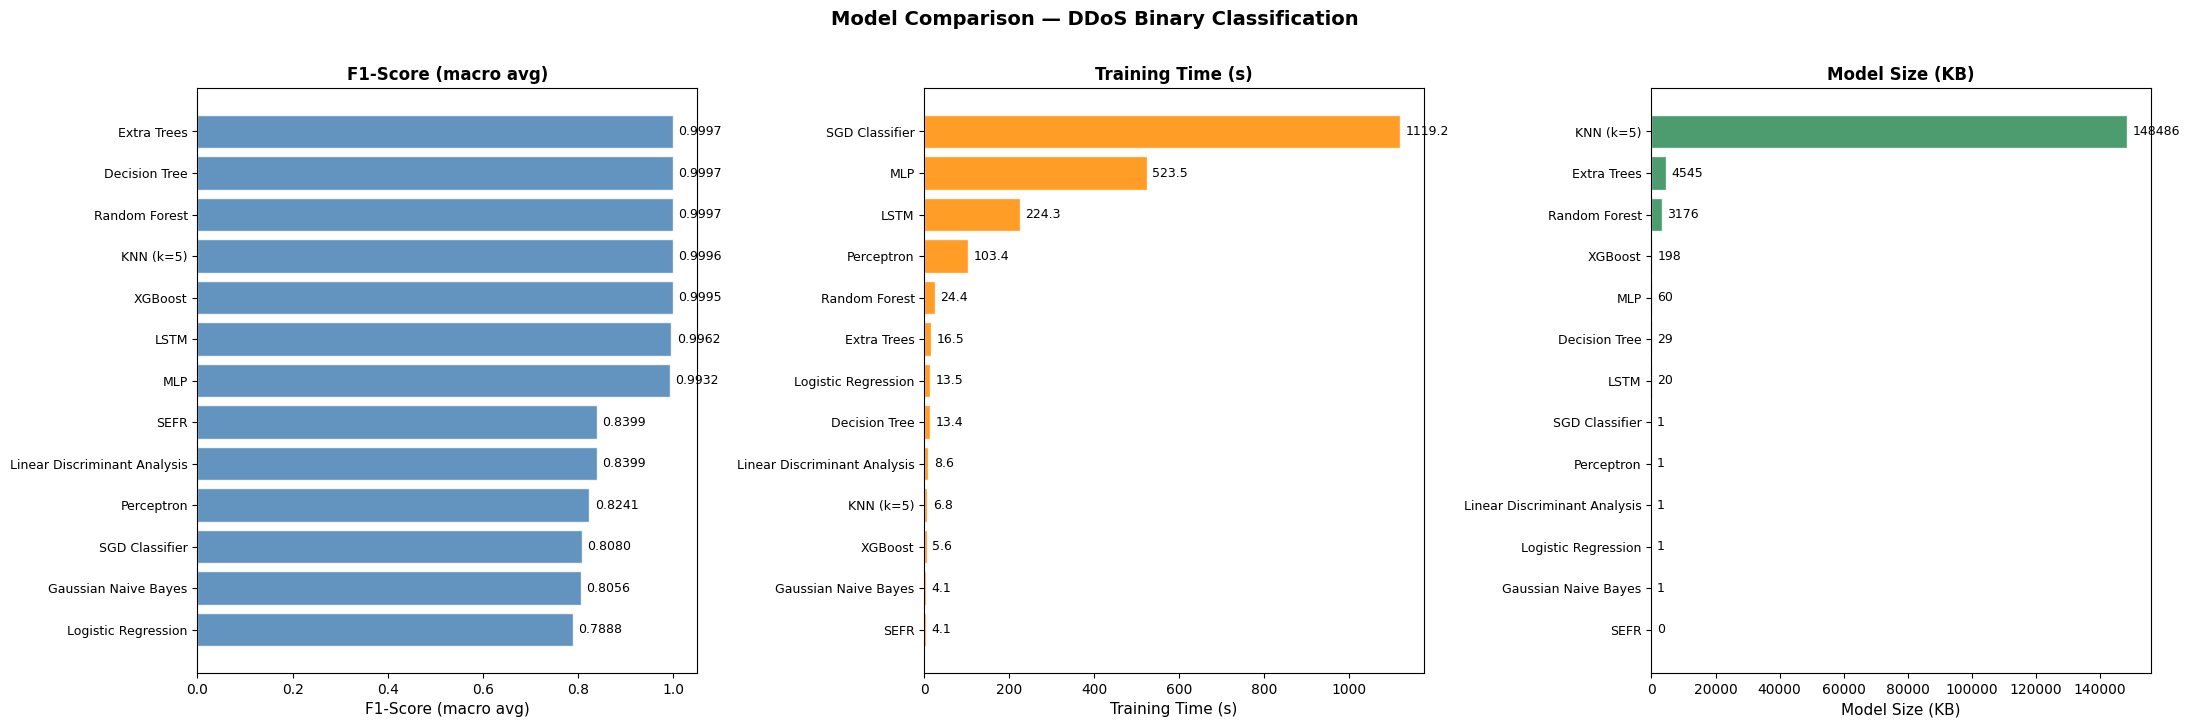

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(22, max(6, len(results) * 0.55)))

metrics = [
    ("F1-Score",       "steelblue",  "F1-Score (macro avg)",     "%.4f", (0, 1.05)),
    ("Train Time (s)", "darkorange", "Training Time (s)",         "%.1f",  None),
    ("Model Size (KB)","seagreen",   "Model Size (KB)",           "%.0f",  None),
]

for ax, (metric, color, title, fmt, xlim) in zip(axes, metrics):
    df_s = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(df_s["Model"], df_s[metric], color=color, alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt=fmt, padding=4, fontsize=9)
    ax.set_xlabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="y", labelsize=9)
    if xlim:
        ax.set_xlim(*xlim)

plt.suptitle("Model Comparison — DDoS Binary Classification", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()